# plotwright demo

Applies plotwright's theme, makes a few example plots, and saves them with the save tool.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import plotwright

saver = plotwright.FigureSaver("figures")

## Apply the theme

`apply_theme` layers the base style with a color cycle. Named palettes, linestyle sets, and marker sets (like "vibrant" and "basic" below) each live as their own small `.mplstyle` file; `apply_theme` reads and combines the ones you ask for.

In [2]:
plotwright.apply_theme("ggplot2", linestyle="basic")
plotwright.list_palettes()

('fishy',
 'ggplot2',
 'ibm',
 'okabe_ito',
 'petroff10',
 'seaborn_deep',
 'tab10',
 'tol_bright',
 'tol_muted',
 'vibrant')

## Compare all palettes

A quick swatch of every built-in palette -- useful for picking one by eye instead of by name.
`palette_colors` reads a palette's colors back without changing the active theme.

WindowsPath('figures/swatches.png')

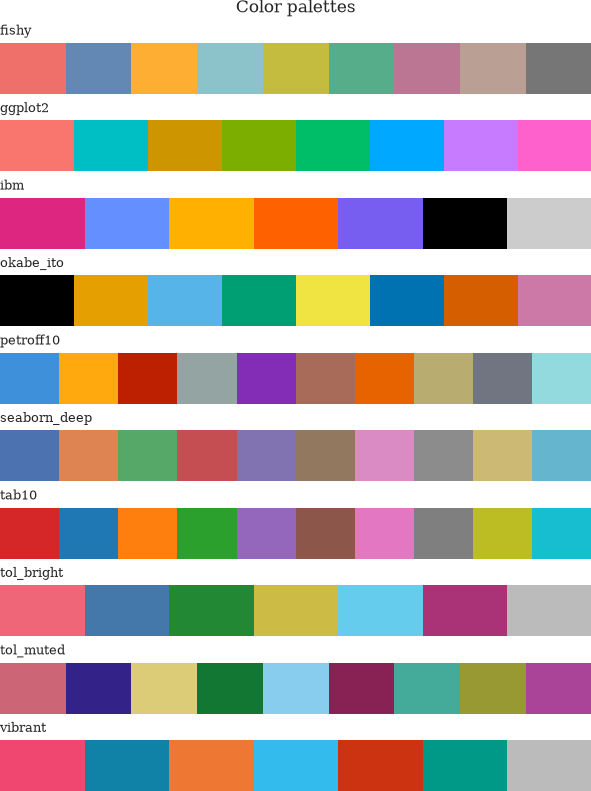

In [3]:
fig_swatches, swatch_axes = plt.subplots(len(plotwright.list_palettes()), 1, figsize=(6, 8), label="swatches")

for row, name in zip(swatch_axes, plotwright.list_palettes(), strict=True):
    colors = plotwright.palette_colors(name)
    row.bar(range(len(colors)), [1] * len(colors), width=1, align="edge", color=colors)
    row.set_xlim(0, len(colors))
    row.set_ylim(0, 1)
    row.set_xticks([])
    row.set_yticks([])
    row.set_title(name, loc="left", fontsize=9)
    for spine in row.spines.values():
        spine.set_visible(False)

fig_swatches.suptitle("Color palettes")
saver.save_figure(fig_swatches, "swatches.png")

## Example plots

A multi-series line plot to show the color + linestyle cycle, and a 2x2 grid to exercise multiple open figures at once.

WindowsPath('figures/lines.png')

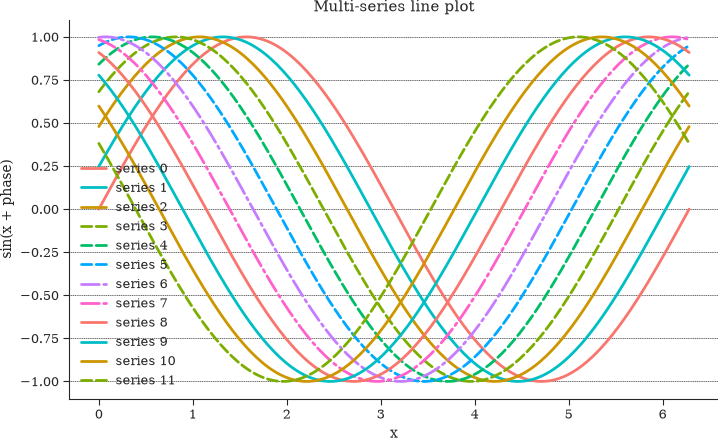

In [4]:
x = np.linspace(0, 2 * np.pi, 200)

fig_lines, ax_lines = plt.subplots(label="lines")
for i in range(12):
    ax_lines.plot(x, np.sin(x + i * 0.25), label=f"series {i}")
ax_lines.set_title("Multi-series line plot")
ax_lines.set_xlabel("x")
ax_lines.set_ylabel("sin(x + phase)")
ax_lines.legend()

saver.save_figure(fig_lines, "lines.png")

WindowsPath('figures/grid.png')

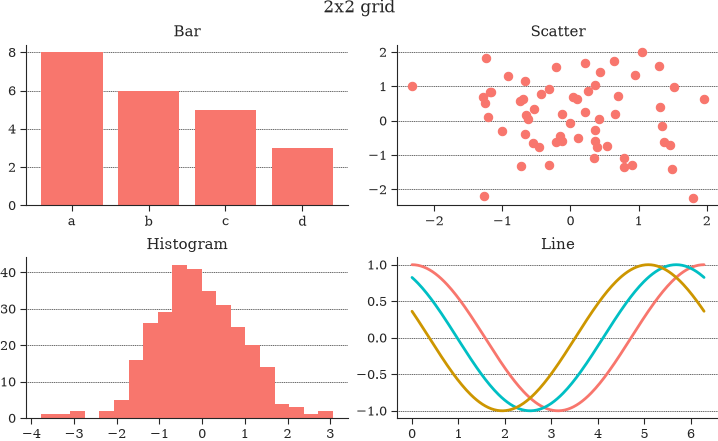

In [5]:
rng = np.random.default_rng(0)

fig_grid, axes = plt.subplots(2, 2, label="grid")

categories = ["a", "b", "c", "d"]
axes[0, 0].bar(categories, rng.integers(1, 10, size=len(categories)))
axes[0, 0].set_title("Bar")

axes[0, 1].scatter(rng.normal(size=60), rng.normal(size=60))
axes[0, 1].set_title("Scatter")

axes[1, 0].hist(rng.normal(size=300), bins=20)
axes[1, 0].set_title("Histogram")

for i in range(3):
    axes[1, 1].plot(x, np.cos(x + i * 0.6))
axes[1, 1].set_title("Line")

fig_grid.suptitle("2x2 grid")

saver.save_figure(fig_grid, "grid.png")

## Save a single subplot

`FigureSaver.save_subplot` crops one panel out of the grid to its tight bbox.

In [6]:
saver.save_subplot(fig_grid, axes[0, 1], "scatter_panel.png")

WindowsPath('figures/scatter_panel.png')

## Align multiple subplots to a common width

`save_subplots_aligned` crops several panels to a shared width (their max), so they line up
column-to-column when placed side by side in a document.

In [7]:
saver.save_subplots_aligned(
    fig_grid,
    [axes[0, 0], axes[0, 1]],
    ["bar_aligned.png", "scatter_aligned.png"],
)

[WindowsPath('figures/bar_aligned.png'),
 WindowsPath('figures/scatter_aligned.png')]

## Use your own colors, scoped to one figure

Pass `colors=` with your own colors instead of a named palette. `apply_theme` only ever mutates `plt.rcParams`, so wrapping the call in `plt.rc_context()` scopes it to whatever you create inside the `with` block -- the theme applied earlier is restored once you exit.

'#F8766D','-'
'#00BFC4','-'
'#CD9600','-'
'#7CAE00','--'
'#00BE67','--'
'#00A9FF','--'
'#C77CFF','-.'
'#FF61CC','-.'


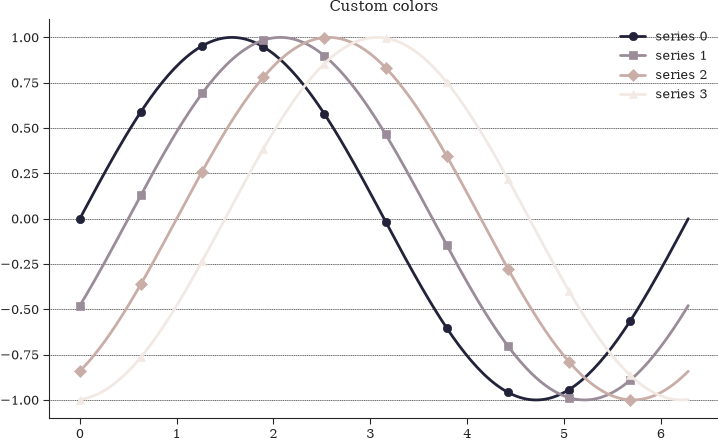

In [8]:
with plt.rc_context():
    plotwright.apply_theme(colors=["#22223B", "#9A8C98", "#C9ADA7", "#F2E9E4"], marker="basic")

    fig_custom, ax_custom = plt.subplots(label="custom_colors")
    for i in range(4):
        ax_custom.plot(x, np.sin(x - i * 0.5), markevery=20, label=f"series {i}")
    ax_custom.set_title("Custom colors")
    ax_custom.legend()

    saver.save_figure(fig_custom, "custom_colors.png")

# outside the `with` block, rcParams are back to what "ggplot2" set earlier
plt.rcParams["axes.prop_cycle"]

## Presentation theme, LaTeX-style text & extra rcParams

`base="presentation"` swaps in a larger-scale, sans-serif layout meant for on-screen slides.
`latex=True` layers a serif + Computer Modern mathtext overlay (no LaTeX installation needed).
`extra_rc` applies any extra rcParams last, overriding everything set above -- either a dict, or
a path to another `.mplstyle` file.

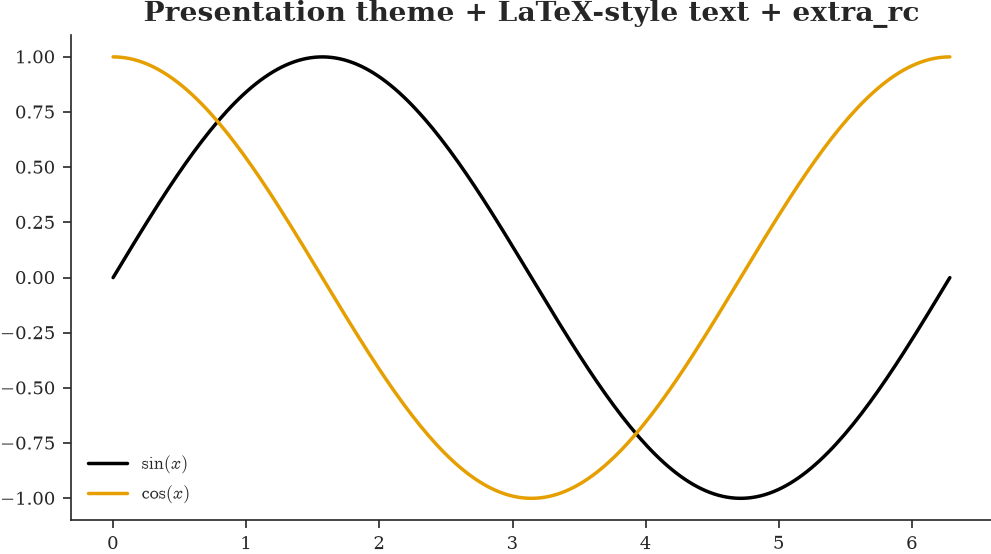

In [9]:
with plt.rc_context():
    plotwright.apply_theme("okabe_ito", base="presentation", latex=True, extra_rc={"axes.grid": False})

    fig_pres, ax_pres = plt.subplots(label="presentation")
    ax_pres.plot(x, np.sin(x), label=r"$\sin(x)$")
    ax_pres.plot(x, np.cos(x), label=r"$\cos(x)$")
    ax_pres.legend()
    ax_pres.set_title("Presentation theme + LaTeX-style text + extra_rc")

    saver.save_figure(fig_pres, "presentation.png")

## Sequential cycling: colors, then markers

By default, an extra linestyle/marker cycle advances in lockstep with color (each series gets a
new color *and* a new marker). Pass `sequential=True` to advance the marker only after the colors
are exhausted instead -- useful when you have more series than colors and want repeats to be
visually distinct.

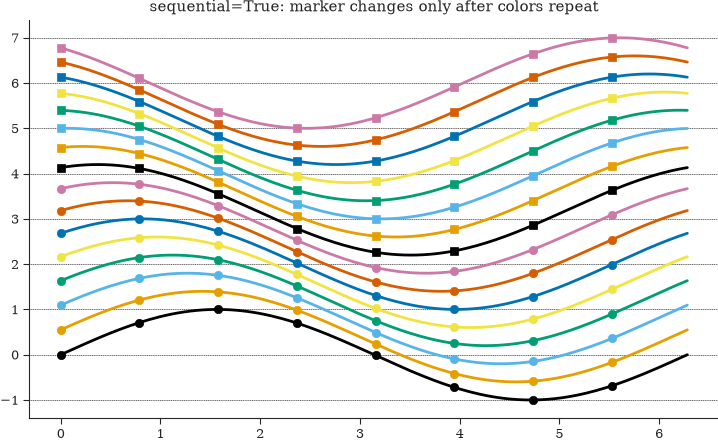

In [10]:
with plt.rc_context():
    plotwright.apply_theme("okabe_ito")
    n_colors = len(plt.rcParams["axes.prop_cycle"])

    plotwright.apply_theme("okabe_ito", marker="basic", sequential=True)
    fig_seq, ax_seq = plt.subplots(label="sequential")
    for i in range(2 * n_colors):  # two full passes through the color cycle
        ax_seq.plot(x, np.sin(x + i * 0.15) + i * 0.4, markevery=25)
    ax_seq.set_title("sequential=True: marker changes only after colors repeat")

    saver.save_figure(fig_seq, "sequential.png")

## Rasterizing heavy artists

`mark_rasterized` flags dense artists (a big scatter, a pcolormesh) to be drawn as a bitmap even
inside an otherwise-vector export, so text and axes stay crisp vector while the heavy artist
doesn't bloat the file.

WindowsPath('figures/raster_demo.pdf')

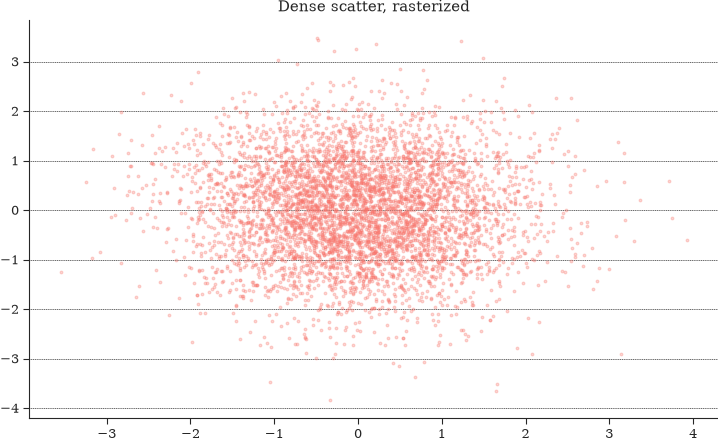

In [11]:
fig_raster, ax_raster = plt.subplots(label="raster")

rng = np.random.default_rng(1)
scatter = ax_raster.scatter(rng.normal(size=5000), rng.normal(size=5000), s=4, alpha=0.3)
plotwright.mark_rasterized(scatter)
ax_raster.set_title("Dense scatter, rasterized")

saver.save_figure(fig_raster, "raster_demo.pdf")